In [1]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torch.nn.functional import sigmoid
from torchvision.models.segmentation import fcn_resnet50, FCN_ResNet50_Weights
from torchvision.models.resnet import ResNet50_Weights
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm
import cv2


Итак, начинаем решать задачу сегментации облаков.
Для начала прочитаем датасет и расшифруем имена фотографий.

In [2]:

# Paths to dataset (assuming downloaded from Kaggle)
train_csv_path = 'D:/Working/HT6/understanding_cloud_organization/train.csv'  # Update with actual path
train_images_path = 'D:/Working/HT6/understanding_cloud_organization/train_images/'  # Update with actual path

# Load and preprocess data
df = pd.read_csv(train_csv_path)
df['Image'] = df['Image_Label'].apply(lambda x: x.split('_')[0])
df['Label'] = df['Image_Label'].apply(lambda x: x.split('_')[1])
df['EncodedPixels'] = df['EncodedPixels'].fillna('')  # Handle NaNs

# Pivot to have one row per image with masks for each class
df_pivoted = df.pivot(index='Image', columns='Label', values='EncodedPixels').reset_index()
classes = ['Fish', 'Flower', 'Gravel', 'Sugar']


В датасете маски хранятся в виде RLE, для нашей задачи перекодируем их в бинарные маски для каждого класса

In [3]:

# Function to decode RLE mask
def rle_decode(mask_rle, shape=(1600, 1400)):
    '''
    mask_rle: run-length as string formatted (start length)
    shape: (height,width) of array to return 
    Returns numpy array, 1 - mask, 0 - background
    '''
    if mask_rle == '':
        return np.zeros(shape, dtype=np.uint8).T
    s = mask_rle.split()
    starts, lengths = [np.asarray(x, dtype=int) for x in (s[0:][::2], s[1:][::2])]
    ends = starts + lengths
    img = np.zeros(shape[0] * shape[1], dtype=np.uint8)
    for lo, hi in zip(starts, ends):
        img[lo:hi] = 1
    return img.reshape(shape).T  # Needed to align to image orientation


Построим датасет по принципу: имя файла, 4 класса масок, в каждом из которых будет либо декодированая маска, либо нулевая, также предусмотрим аугментации

In [4]:

# Custom Dataset
class CloudDataset(Dataset):
    def __init__(self, df, img_dir, transform=None, subset='train'):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform
        self.subset = subset

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['Image'])
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        masks = []
        for cls in classes:
            rle = row[cls] if cls in row else ''
            mask = rle_decode(rle, shape=(image.shape[1], image.shape[0]))
            masks.append(mask)

        mask = np.stack(masks, axis=-1).astype(np.float32)
        
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
        
        return image, mask.permute(2, 0, 1)  # Channels first for mask


Зададим трансформации картинок в необходимый размер и искажения для тренировочного набора

In [5]:

# Transforms
train_transform = A.Compose([
    A.Resize(320, 320),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(320, 320),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])


Делим на тренировочный и тестовый набор

In [6]:

# Split data
train_df, val_df = train_test_split(df_pivoted, test_size=0.05, random_state=42)

train_ds = CloudDataset(train_df, train_images_path, transform=train_transform)
val_ds = CloudDataset(val_df, train_images_path, transform=val_transform)

train_loader = DataLoader(train_ds, batch_size=10, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=10, shuffle=False, num_workers=0)


Для удобства сделаем функцию, задающую необходимые параметры модели

In [7]:
def get_fcn_resnet50_multilabel(num_classes=4, pretrained=True, aux_loss=False):
    if pretrained:
        weights = FCN_ResNet50_Weights.DEFAULT
    else:
        weights = None

    model = fcn_resnet50(
        weights=weights,
        progress=True,
        num_classes=21,
        aux_loss=aux_loss,
        weights_backbone= ResNet50_Weights.IMAGENET1K_V1
    )

    inplanes = model.classifier[4].in_channels
    model.classifier[4] = nn.Conv2d(inplanes, num_classes, kernel_size=1)

    if aux_loss and hasattr(model, 'aux_classifier'):
        aux_inplanes = model.aux_classifier[4].in_channels
        model.aux_classifier[4] = nn.Conv2d(aux_inplanes, num_classes, kernel_size=1)

    return model



Напишем функцию потерь на основе Dice коэффициента

In [8]:
class MultiLabelDiceBCELoss(nn.Module):
    def __init__(self, alpha=0.5, beta=0.5, smooth=1e-6):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.smooth = smooth

    def dice_loss(self, pred, target):
        pred = torch.sigmoid(pred)
        inter = (pred * target).sum(dim=(2,3))
        union = pred.sum(dim=(2,3)) + target.sum(dim=(2,3))
        dice = (2 * inter + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()

    def forward(self, pred, target):
        # pred:   [B, C, H, W]
        # target: [B, C, H, W] float 0/1
        bce = nn.functional.binary_cross_entropy_with_logits(pred, target, reduction='mean')
        dice = self.dice_loss(pred, target)
        return self.alpha * bce + self.beta * dice



И сам коэффициент для контроля показаний

In [9]:
def multi_label_dice_coeff(pred, target, smooth=1e-6, thresh=0.5):
    pred = (torch.sigmoid(pred) > thresh).float()
    inter = (pred * target).sum(dim=(2,3))
    union = pred.sum(dim=(2,3)) + target.sum(dim=(2,3))
    dice_per_class = (2 * inter + smooth) / (union + smooth)
    return dice_per_class.mean().cpu()  # mean по классам и батчу



Цикл обучения, в нем предусмотрено постепенное изменение learnng rate и ранняя остановка при отсутствии прогресса обучения модели

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = get_fcn_resnet50_multilabel(num_classes=4, pretrained=False)
model = model.to(device)

criterion = MultiLabelDiceBCELoss(alpha=0.3, beta=0.7)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.3, patience=4)

num_epochs = 100
patience = 10
best_dice = -1
counter = 0
train_hist, val_hist = [], []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for images, masks in tqdm(train_loader):
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)['out']
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_hist.append(train_loss)

    # Валидация
    model.eval()
    val_dice, val_loss = 0.0, 0.0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)['out']
            val_loss += criterion(outputs, masks).item()
            val_dice += multi_label_dice_coeff(outputs, masks)

    val_loss /= len(val_loader)
    val_dice /= len(val_loader)
    val_hist.append(val_dice)

    print(f"Epoch {epoch+1:2d} | Train loss: {train_loss:.4f} | Val Dice: {val_dice:.4f} | lr: {optimizer.param_groups[0]['lr']:.1e}")

    scheduler.step(val_dice)

    # Early stopping
    if val_dice > best_dice:
        best_dice = val_dice
        torch.save(model.state_dict(), "best_fcn_clouds.pth")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping")
            break


100%|██████████| 527/527 [33:43<00:00,  3.84s/it]


Epoch  1 | Train loss: 0.6165 | Val Dice: 0.4767 | lr: 1.0e-04


100%|██████████| 527/527 [30:11<00:00,  3.44s/it]


Epoch  2 | Train loss: 0.5948 | Val Dice: 0.4897 | lr: 1.0e-04


100%|██████████| 527/527 [30:45<00:00,  3.50s/it]


...

Epoch 17 | Train loss: 0.4984 | Val Dice: 0.5083 | lr: 3.0e-05


100%|██████████| 527/527 [29:59<00:00,  3.42s/it]


Epoch 18 | Train loss: 0.4921 | Val Dice: 0.5127 | lr: 3.0e-05


100%|██████████| 527/527 [29:49<00:00,  3.40s/it]


Epoch 19 | Train loss: 0.4874 | Val Dice: 0.4871 | lr: 3.0e-05
Early stopping


Сохряняем значения для возможного использования

In [11]:
history_df = pd.DataFrame({
    'epoch': range(1, len(train_hist) + 1),
    'train_loss': train_hist,
    'val_dice': val_hist
})

# Save to file
history_df.to_csv('training_history.csv', index=False)
print("Training history saved to: training_history.csv")

Training history saved to: training_history.csv


График обучения модели демонстрирует переобучаемость модели, что с одной стороны может говорить о необходимости доработки модели и цикла обучения, а с другой допускает неточности разметки и "условность" обозначеных прямоугольных масок

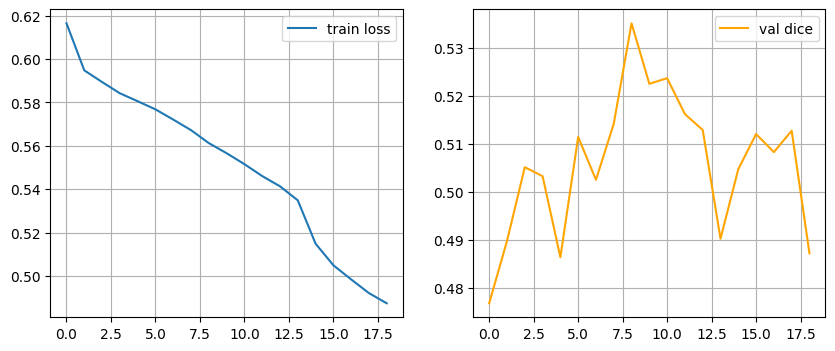

Лучший Dice на валидации: 0.5352


In [12]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(train_hist, label='train loss')
plt.legend(); plt.grid(True)
plt.subplot(1,2,2)
plt.plot(val_hist, label='val dice', color='orange')
plt.legend(); plt.grid(True)
plt.show()

print(f"Лучший Dice на валидации: {best_dice:.4f}")

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = get_fcn_resnet50_multilabel(
    num_classes=4, 
    pretrained=False,  # ← important: don't load pretrained again, we want our weights
    aux_loss=False     # use the same value as during training
)

# 2. Load the saved weights
model.load_state_dict(torch.load("best_fcn_clouds.pth", map_location=device))

# 3. Move to device and set to evaluation mode (if you're doing inference)
model.to(device)

FCN(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequenti

Ну и наконец посмотрим в сравнении на истинные и предсказанные маски, чтобы оценить насколько они далеки от правды

In [14]:
def visualize_overlay(model, dataloader, device, num_samples=4, threshold=0.5):
    model.eval()
    samples_shown = 0
    
    colors = [
        (255, 0,   0),   # Fish - red
        (0,   255, 0),   # Flower - green
        (0,   0,   255), # Gravel - blue
        (255, 255, 0)    # Sugar - yellow
    ]
    
    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device)
            outputs = model(images)['out']
            preds = sigmoid(outputs) > threshold
            
            images_np = images.cpu().numpy()
            gt_np     = masks.cpu().numpy()
            pred_np   = preds.float().cpu().numpy()
            
            for i in range(images_np.shape[0]):
                if samples_shown >= num_samples:
                    return
                
                img = np.transpose(images_np[i], (1,2,0))
                img = (img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]))
                img = (np.clip(img, 0, 1) * 255).astype(np.uint8)
                
                # Create color overlays
                gt_color = np.zeros_like(img)
                pred_color = np.zeros_like(img)
                
                for c in range(4):
                    gt_mask = gt_np[i, c] > 0.5
                    pred_mask = pred_np[i, c] > 0.5
                    
                    gt_color[gt_mask] = colors[c]
                    pred_color[pred_mask] = colors[c]
                
                # Blend overlays on image
                gt_overlay = cv2.addWeighted(img, 0.6, gt_color, 0.4, 0)
                pred_overlay = cv2.addWeighted(img, 0.6, pred_color, 0.4, 0)
                
                # Plot
                fig, axes = plt.subplots(1, 2, figsize=(15, 5))

                axes[0].imshow(gt_overlay)
                axes[0].set_title("Ground Truth Overlay")
                axes[0].axis('off')
                
                axes[1].imshow(pred_overlay)
                axes[1].set_title("Prediction Overlay")
                axes[1].axis('off')
                
                plt.tight_layout()
                plt.show()
                
                samples_shown += 1


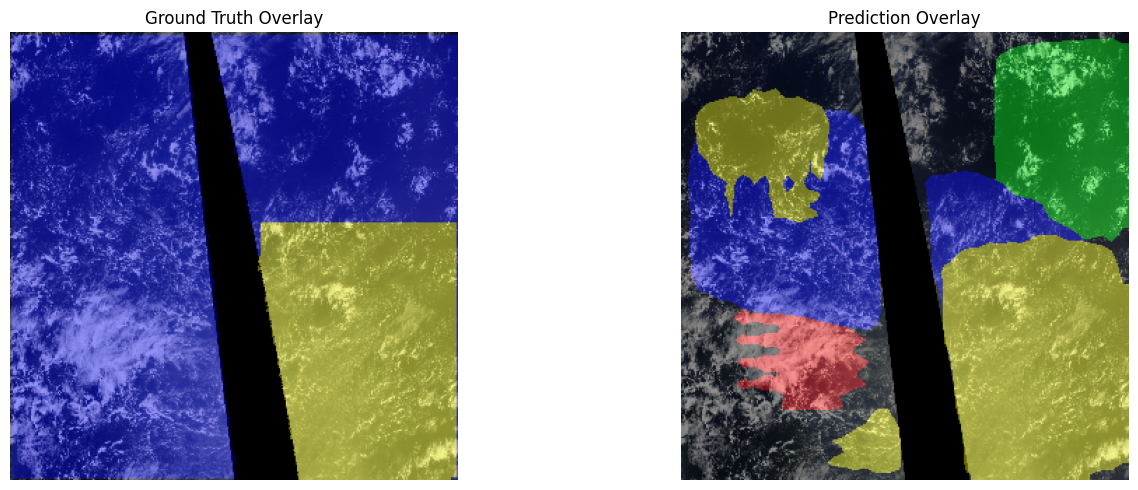

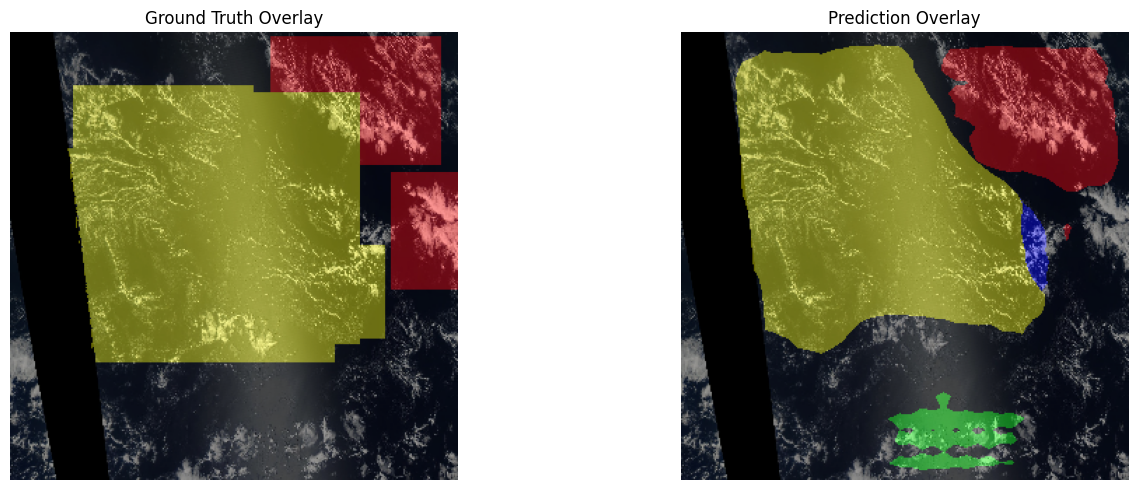

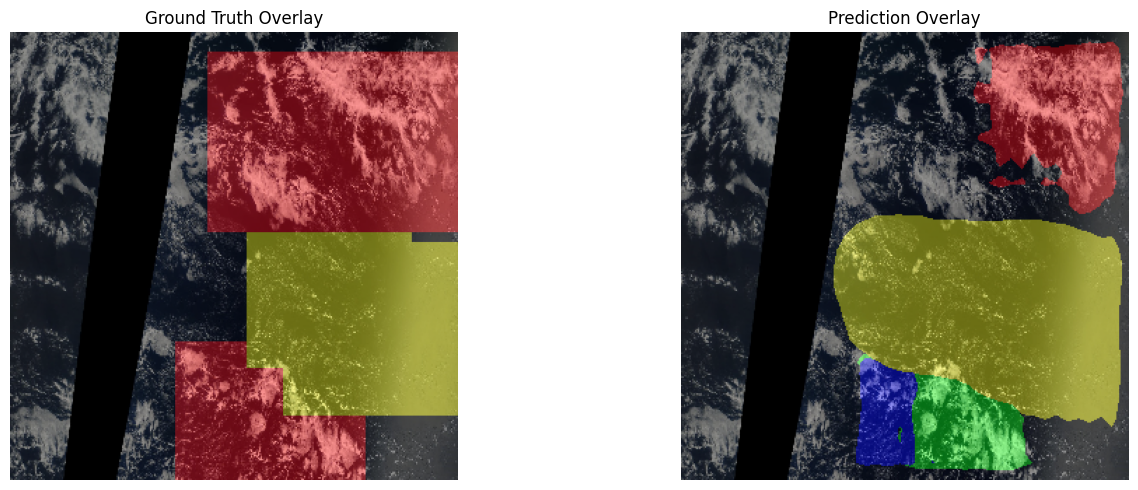

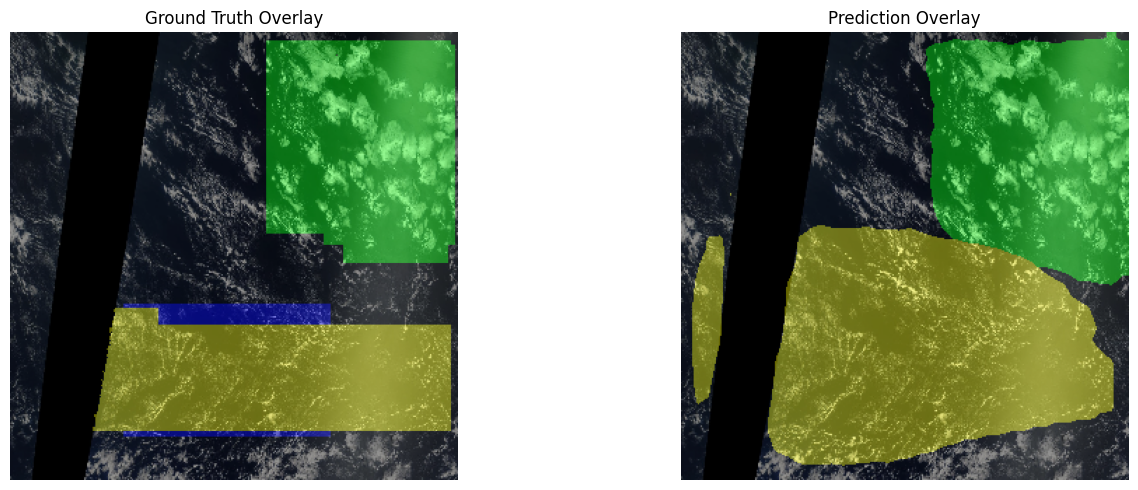

In [15]:
visualize_overlay(model, val_loader, device, num_samples=4)

Можно отметить довольно высокий процент совпадений областей истинных и предсказанных масок, не исключено, что модели, приспособленные для работы с прямоугольными масками продемонстрировали бы лучшие показатели, равно как и приведение предсказанных масок к прямоугольной форме. Нельзя не учесть тот факт, что предсказаные маски действительно содержат визуально отличающиеся друг от друга виды облаков, что также может говорить о высоком качестве предсказываемых масок.